# 02 – Preprocessing, Feature Engineering & ISPU
**Proyek Capstone – Sistem Deteksi Anomali Kualitas Udara**  
**Kelompok Aeris | PENS 2026**  
**PIC: Linda Anggara Wati – Data, EDA, Feature Engineering & ML**

---
**Minggu 2 | 4 Mei – 10 Mei 2026**  
Fase: Phase 1 → Phase 2 – Preprocessing & Model Awal

**Checklist Minggu 2 (Linda):**
- [x] Handle missing values (forward fill / interpolasi linear)
- [x] Hapus duplikasi berdasarkan timestamp
- [x] Tambah kolom `time_segment` (PAGI / SIANG / SORE_MALAM)
- [x] Feature Engineering fitur lag (pm25_lag_1h, _3h, _24h — semua 5 polutan)
- [x] Feature Engineering fitur rolling (mean_3h, mean_24h, std_24h, max_24h)
- [x] Feature Engineering fitur perubahan (diff_1h, pct_change_1h)
- [x] Fitur waktu (hour, day_of_week, month, is_weekend)
- [x] Hitung ISPU per polutan (rumus Permen LHK 14/2020)
- [x] Tambah kolom ispu_category
- [x] Normalisasi fitur numerik (StandardScaler)
- [x] Simpan data processed ke `data/processed/`
- [x] Buat handover doc akhir minggu

**Input:**  `data/raw/surabaya_airquality_raw.csv` (output Minggu 1)  
**Output:** `data/processed/surabaya_processed.csv` + `data/processed/surabaya_scaled.csv`

## 1. Setup & Load Data Raw

In [21]:
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings("ignore")

# ✅ TAMBAHKAN INI — pindah ke root project
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
os.chdir(ROOT)
print(f"Working directory: {os.getcwd()}")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

# Buat folder di root project (bukan di dalam notebooks/)
for folder in ["data/raw", "data/processed", "models", "reports"]:
    os.makedirs(folder, exist_ok=True)

RAW_PATH = "data/raw/surabaya_airquality_raw.csv"
POLUTAN  = ["pm25", "pm10", "co", "no2", "o3"]
METEO    = ["temperature_2m", "relative_humidity",
            "wind_speed_10m", "wind_direction_10m", "precipitation"]

print("✅ Library loaded")

Working directory: d:\mlops\aeris-air-quality
✅ Library loaded


In [22]:
# ── Coba load dari CSV; jika belum ada, fetch ulang ─────────────
if os.path.exists(RAW_PATH):
    df = pd.read_csv(RAW_PATH, parse_dates=["time"])
    print(f"✅ Data dimuat dari file: {RAW_PATH}")
else:
    print("⚠️  File raw belum ada — fetch ulang dari Open-Meteo...")
    LAT, LON   = -7.2575, 112.7521
    START_DATE = "2026-01-01"
    END_DATE   = (datetime.today() - timedelta(days=1)).strftime("%Y-%m-%d")

    resp_aq = requests.get(
        "https://air-quality-api.open-meteo.com/v1/air-quality",
        params={"latitude": LAT, "longitude": LON,
                "hourly": ["pm2_5","pm10","carbon_monoxide",
                           "nitrogen_dioxide","ozone"],
                "timezone": "Asia/Jakarta",
                "start_date": START_DATE, "end_date": END_DATE}
    )
    resp_w = requests.get(
        "https://api.open-meteo.com/v1/forecast",
        params={"latitude": LAT, "longitude": LON,
                "hourly": ["temperature_2m","relative_humidity_2m",
                           "wind_speed_10m","wind_direction_10m","precipitation"],
                "timezone": "Asia/Jakarta",
                "start_date": START_DATE, "end_date": END_DATE}
    )
    df_aq = pd.DataFrame(resp_aq.json()["hourly"])
    df_w  = pd.DataFrame(resp_w.json()["hourly"])
    df_aq["time"] = pd.to_datetime(df_aq["time"])
    df_w["time"]  = pd.to_datetime(df_w["time"])
    df_w.rename(columns={"relative_humidity_2m": "relative_humidity"}, inplace=True)
    df = pd.merge(df_aq, df_w, on="time", how="inner")
    df.rename(columns={"pm2_5": "pm25", "carbon_monoxide": "co",
                       "nitrogen_dioxide": "no2", "ozone": "o3"}, inplace=True)
    df.to_csv(RAW_PATH, index=False)
    print(f"✅ Data difetch dan disimpan ke {RAW_PATH}")

print(f"\nShape  : {df.shape}")
print(f"Kolom  : {list(df.columns)}")
print(f"Rentang: {df['time'].min()}  →  {df['time'].max()}")
df.head(3)

✅ Data dimuat dari file: data/raw/surabaya_airquality_raw.csv

Shape  : (3096, 11)
Kolom  : ['time', 'pm25', 'pm10', 'co', 'no2', 'o3', 'temperature_2m', 'relative_humidity', 'wind_speed_10m', 'wind_direction_10m', 'precipitation']
Rentang: 2026-01-01 00:00:00  →  2026-05-09 23:00:00


,time,pm25,pm10,co,no2,o3,temperature_2m,relative_humidity,wind_speed_10m,wind_direction_10m,precipitation
0,2026-01-01 00:00:00,100.4,100.6,961.0,79.6,3.0,25.7,84,7.6,277,0.0
1,2026-01-01 01:00:00,110.1,110.6,832.0,77.6,3.0,25.4,87,6.9,295,0.0
2,2026-01-01 02:00:00,116.9,118.3,657.0,75.2,1.0,25.0,89,6.7,284,0.0


## 2. Handle Missing Values
Strategi:
- **Polutan (PM2.5, PM10, CO, NO2, O3):** interpolasi linear — cocok untuk data time series
- **Meteorologi:** forward fill — nilai cuaca berubah lambat
- Setelah fill, cek sisa NaN; drop jika sangat sedikit (<1%)

In [23]:
print("=" * 55)
print("2.1  MISSING VALUES SEBELUM HANDLE")
print("=" * 55)
mv_before = df.isnull().sum()
mv_before = mv_before[mv_before > 0]
if mv_before.empty:
    print("✅ Tidak ada missing values di data raw.")
else:
    print(mv_before)

2.1  MISSING VALUES SEBELUM HANDLE
✅ Tidak ada missing values di data raw.


In [24]:
df = df.sort_values("time").reset_index(drop=True)

# Polutan → interpolasi linear
for col in POLUTAN:
    before = df[col].isna().sum()
    df[col] = df[col].interpolate(method="linear", limit_direction="both")
    after  = df[col].isna().sum()
    if before > 0:
        print(f"  {col}: {before} NaN → {after} NaN (interpolasi linear)")

# Meteorologi → forward fill lalu backward fill
for col in METEO:
    before = df[col].isna().sum()
    df[col] = df[col].ffill().bfill()
    after  = df[col].isna().sum()
    if before > 0:
        print(f"  {col}: {before} NaN → {after} NaN (forward fill)")

# Drop sisa NaN jika ada (sangat sedikit)
sisa_nan = df.isnull().sum().sum()
if sisa_nan > 0:
    df = df.dropna()
    print(f"  Sisa {sisa_nan} NaN di-drop.")

print(f"\n✅ Missing values handled. Shape sekarang: {df.shape}")


✅ Missing values handled. Shape sekarang: (3096, 11)


## 3. Hapus Duplikasi Berdasarkan Timestamp

In [25]:
dup_count = df.duplicated(subset=["time"]).sum()
print(f"Duplikasi timestamp ditemukan: {dup_count}")

if dup_count > 0:
    df = df.drop_duplicates(subset=["time"], keep="first")
    print(f"✅ Duplikasi dihapus. Shape baru: {df.shape}")
else:
    print("✅ Tidak ada duplikasi timestamp.")

df = df.reset_index(drop=True)

Duplikasi timestamp ditemukan: 0
✅ Tidak ada duplikasi timestamp.


## 4. Fitur Waktu & Segmentasi Waktu
Tambah kolom `time_segment` sesuai spesifikasi tim:
- **PAGI**: jam 06:00 – 11:59
- **SIANG**: jam 12:00 – 17:59
- **SORE_MALAM**: jam 18:00 – 05:59

In [26]:
df["hour"]        = df["time"].dt.hour
df["day_of_week"] = df["time"].dt.dayofweek          # 0=Senin, 6=Minggu
df["month"]       = df["time"].dt.month
df["is_weekend"]  = (df["day_of_week"] >= 5).astype(int)  # 1=weekend

def assign_segment(hour):
    if 6 <= hour <= 11:
        return "PAGI"
    elif 12 <= hour <= 17:
        return "SIANG"
    else:
        return "SORE_MALAM"

df["time_segment"] = df["hour"].apply(assign_segment)

print("✅ Fitur waktu & segmentasi selesai")
print("\nDistribusi time_segment:")
print(df["time_segment"].value_counts())
print("\nContoh:")
df[["time", "hour", "day_of_week", "month", "is_weekend", "time_segment"]].head(8)

✅ Fitur waktu & segmentasi selesai

Distribusi time_segment:
time_segment
SORE_MALAM    1548
PAGI           774
SIANG          774
Name: count, dtype: int64

Contoh:


,time,hour,day_of_week,month,is_weekend,time_segment
0,2026-01-01 00:00:00,0,3,1,0,SORE_MALAM
1,2026-01-01 01:00:00,1,3,1,0,SORE_MALAM
2,2026-01-01 02:00:00,2,3,1,0,SORE_MALAM
3,2026-01-01 03:00:00,3,3,1,0,SORE_MALAM
4,2026-01-01 04:00:00,4,3,1,0,SORE_MALAM
5,2026-01-01 05:00:00,5,3,1,0,SORE_MALAM
6,2026-01-01 06:00:00,6,3,1,0,PAGI
7,2026-01-01 07:00:00,7,3,1,0,PAGI


## 5. Feature Engineering – Fitur Lag
Dibuat untuk **semua 5 polutan**: lag 1 jam, 3 jam, 24 jam

In [27]:
lag_windows = [1, 3, 24]

for polutan in POLUTAN:
    for lag in lag_windows:
        col_name = f"{polutan}_lag_{lag}h"
        df[col_name] = df[polutan].shift(lag)

lag_cols = [f"{p}_lag_{l}h" for p in POLUTAN for l in lag_windows]
print(f"✅ Fitur lag selesai — {len(lag_cols)} kolom baru")
print("Kolom lag:", lag_cols[:6], "...")
df[["time", "pm25"] + [f"pm25_lag_{l}h" for l in lag_windows]].head(8)

✅ Fitur lag selesai — 15 kolom baru
Kolom lag: ['pm25_lag_1h', 'pm25_lag_3h', 'pm25_lag_24h', 'pm10_lag_1h', 'pm10_lag_3h', 'pm10_lag_24h'] ...


,time,pm25,pm25_lag_1h,pm25_lag_3h,pm25_lag_24h
0,2026-01-01 00:00:00,100.4,NaN,NaN,NaN
1,2026-01-01 01:00:00,110.1,100.4,NaN,NaN
2,2026-01-01 02:00:00,116.9,110.1,NaN,NaN
3,2026-01-01 03:00:00,123.4,116.9,100.4,NaN
4,2026-01-01 04:00:00,136.0,123.4,110.1,NaN
5,2026-01-01 05:00:00,147.6,136.0,116.9,NaN
6,2026-01-01 06:00:00,143.9,147.6,123.4,NaN
7,2026-01-01 07:00:00,102.2,143.9,136.0,NaN


## 6. Feature Engineering – Fitur Rolling
Rolling mean 3h, mean 24h, std 24h, max 24h — untuk **semua 5 polutan**

In [28]:
rolling_cfg = [
    ("rolling_mean_3h",  3,  "mean"),
    ("rolling_mean_24h", 24, "mean"),
    ("rolling_std_24h",  24, "std"),
    ("rolling_max_24h",  24, "max"),
]

for polutan in POLUTAN:
    for suffix, window, func in rolling_cfg:
        col_name = f"{polutan}_{suffix}"
        rolled = df[polutan].rolling(window=window, min_periods=1)
        df[col_name] = getattr(rolled, func)()

rolling_cols = [f"{p}_{s}" for p in POLUTAN for s, *_ in rolling_cfg]
print(f"✅ Fitur rolling selesai — {len(rolling_cols)} kolom baru")
df[["time", "pm25",
    "pm25_rolling_mean_3h",
    "pm25_rolling_mean_24h",
    "pm25_rolling_std_24h",
    "pm25_rolling_max_24h"]].head(8)

✅ Fitur rolling selesai — 20 kolom baru

,time,pm25,pm25_rolling_mean_3h,pm25_rolling_mean_24h,pm25_rolling_std_24h,pm25_rolling_max_24h
0,2026-01-01 00:00:00,100.4,100.400000,100.400000,NaN,100.4
1,2026-01-01 01:00:00,110.1,105.250000,105.250000,6.858936,110.1
2,2026-01-01 02:00:00,116.9,109.133333,109.133333,8.292366,116.9
3,2026-01-01 03:00:00,123.4,116.800000,112.700000,9.834972,123.4
4,2026-01-01 04:00:00,136.0,125.433333,117.360000,13.458195,136.0
5,2026-01-01 05:00:00,147.6,135.666667,122.400000,17.242622,147.6
6,2026-01-01 06:00:00,143.9,142.500000,125.471429,17.714186,147.6
7,2026-01-01 07:00:00,102.2,131.233333,122.562500,18.348292,147.6


## 7. Feature Engineering – Fitur Perubahan
Diff 1h dan pct_change 1h — untuk **semua 5 polutan**

In [29]:
for polutan in POLUTAN:
    df[f"{polutan}_diff_1h"]       = df[polutan].diff(1)
    df[f"{polutan}_pct_change_1h"] = df[polutan].pct_change(1).replace(
        [np.inf, -np.inf], np.nan
    )

change_cols = [f"{p}_{t}" for p in POLUTAN
               for t in ["diff_1h", "pct_change_1h"]]
print(f"✅ Fitur perubahan selesai — {len(change_cols)} kolom baru")
df[["time", "pm25",
    "pm25_diff_1h",
    "pm25_pct_change_1h"]].head(8)

✅ Fitur perubahan selesai — 10 kolom baru


,time,pm25,pm25_diff_1h,pm25_pct_change_1h
0,2026-01-01 00:00:00,100.4,NaN,NaN
1,2026-01-01 01:00:00,110.1,9.7,0.096614
2,2026-01-01 02:00:00,116.9,6.8,0.061762
3,2026-01-01 03:00:00,123.4,6.5,0.055603
4,2026-01-01 04:00:00,136.0,12.6,0.102107
5,2026-01-01 05:00:00,147.6,11.6,0.085294
6,2026-01-01 06:00:00,143.9,-3.7,-0.025068
7,2026-01-01 07:00:00,102.2,-41.7,-0.289785


## 8. Hitung ISPU per Polutan (Permen LHK No. 14 Tahun 2020)
Formula:
$$ISPU = \frac{I_{hi} - I_{lo}}{C_{hi} - C_{lo}} \times (C_a - C_{lo}) + I_{lo}$$

ISPU final = nilai tertinggi dari semua polutan pada timestamp tersebut.

In [30]:
# ── Breakpoint ISPU KLHK per polutan ────────────────────────────
# Format: (C_lo, C_hi, I_lo, I_hi)
BREAKPOINTS = {
    # PM2.5 (µg/m³, rata-rata 24 jam)
    "pm25": [
        (0.0,   15.5,   0,  50),
        (15.5,  55.4,  51, 100),
        (55.4, 150.4, 101, 200),
        (150.4, 250.4, 201, 300),
        (250.4, 500.4, 301, 500),
    ],
    # PM10 (µg/m³, rata-rata 24 jam)
    "pm10": [
        (0,    50,    0,  50),
        (50,  150,   51, 100),
        (150, 350,  101, 200),
        (350, 420,  201, 300),
        (420, 600,  301, 500),
    ],
    # CO (µg/m³, rata-rata 1 jam — Open-Meteo dalam µg/m³)
    "co": [
        (0,      4000,    0,  50),
        (4000,  8000,    51, 100),
        (8000,  15000,  101, 200),
        (15000, 30000,  201, 300),
        (30000, 45000,  301, 500),
    ],
    # NO2 (µg/m³, rata-rata 1 jam)
    "no2": [
        (0,    80,    0,  50),
        (80,  200,   51, 100),
        (200, 1130,  101, 200),
        (1130, 2260, 201, 300),
        (2260, 3000, 301, 500),
    ],
    # O3 (µg/m³, rata-rata 1 jam)
    "o3": [
        (0,    120,   0,  50),
        (120,  235,  51, 100),
        (235,  400, 101, 200),
        (400,  800, 201, 300),
        (800, 1000, 301, 500),
    ],
}

def hitung_ispu(konsentrasi, breakpoints):
    """Konversi konsentrasi → nilai ISPU (Permen LHK 14/2020)."""
    if pd.isna(konsentrasi) or konsentrasi < 0:
        return np.nan
    for C_lo, C_hi, I_lo, I_hi in breakpoints:
        if C_lo <= konsentrasi <= C_hi:
            return round(
                ((I_hi - I_lo) / (C_hi - C_lo)) * (konsentrasi - C_lo) + I_lo, 1
            )
    return 500.0  # di atas breakpoint tertinggi

def ispu_to_kategori(ispu):
    """Nilai ISPU → kategori KLHK."""
    if pd.isna(ispu):  return "N/A"
    if ispu <= 50:     return "Baik"
    elif ispu <= 100:  return "Sedang"
    elif ispu <= 200:  return "Tidak Sehat"
    elif ispu <= 300:  return "Sangat Tidak Sehat"
    else:              return "Berbahaya"

def ispu_to_warna(ispu):
    """Nilai ISPU → warna KLHK."""
    if pd.isna(ispu):  return "Abu"
    if ispu <= 50:     return "Hijau"
    elif ispu <= 100:  return "Biru"
    elif ispu <= 200:  return "Kuning"
    elif ispu <= 300:  return "Merah"
    else:              return "Hitam"

# Hitung ISPU per polutan
for polutan, bp in BREAKPOINTS.items():
    df[f"ispu_{polutan}"] = df[polutan].apply(lambda x: hitung_ispu(x, bp))

# ISPU final = nilai tertinggi dari semua polutan
ispu_cols     = [f"ispu_{p}" for p in POLUTAN]
df["ispu_final"]    = df[ispu_cols].max(axis=1)
df["ispu_category"] = df["ispu_final"].apply(ispu_to_kategori)
df["ispu_color"]    = df["ispu_final"].apply(ispu_to_warna)

print("✅ ISPU dihitung untuk semua polutan")
print("\nDistribusi ispu_category:")
print(df["ispu_category"].value_counts())
print()
df[["time", "pm25", "ispu_pm25", "ispu_final", "ispu_category", "ispu_color"]].head(8)

✅ ISPU dihitung untuk semua polutan

Distribusi ispu_category:
ispu_category
Sedang         2400
Tidak Sehat     525
Baik            171
Name: count, dtype: int64



,time,pm25,ispu_pm25,ispu_final,ispu_category,ispu_color
0,2026-01-01 00:00:00,100.4,147.9,147.9,Tidak Sehat,Kuning
1,2026-01-01 01:00:00,110.1,158.0,158.0,Tidak Sehat,Kuning
2,2026-01-01 02:00:00,116.9,165.1,165.1,Tidak Sehat,Kuning
3,2026-01-01 03:00:00,123.4,171.9,171.9,Tidak Sehat,Kuning
4,2026-01-01 04:00:00,136.0,185.0,185.0,Tidak Sehat,Kuning
5,2026-01-01 05:00:00,147.6,197.1,197.1,Tidak Sehat,Kuning
6,2026-01-01 06:00:00,143.9,193.2,193.2,Tidak Sehat,Kuning
7,2026-01-01 07:00:00,102.2,149.8,149.8,Tidak Sehat,Kuning


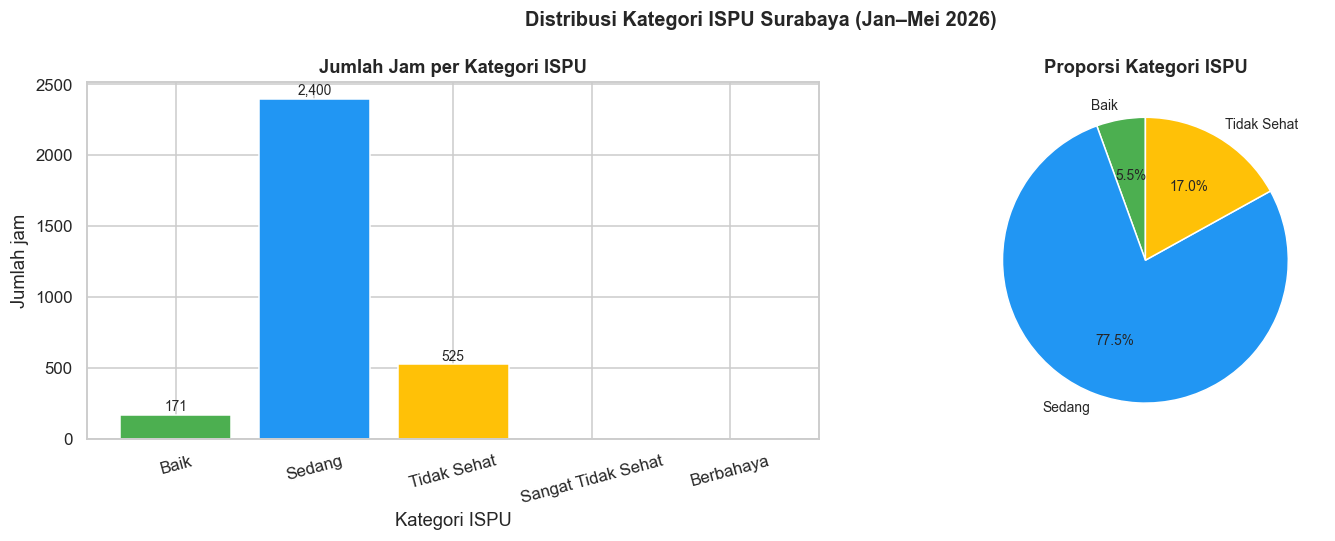

💾 Disimpan → reports/ispu_kategori_distribusi.png


In [31]:
# ── Visualisasi distribusi ISPU per kategori ─────────────────────
warna_map = {
    "Baik": "#4CAF50",
    "Sedang": "#2196F3",
    "Tidak Sehat": "#FFC107",
    "Sangat Tidak Sehat": "#F44336",
    "Berbahaya": "#212121",
    "N/A": "#9E9E9E",
}
urutan    = ["Baik", "Sedang", "Tidak Sehat", "Sangat Tidak Sehat", "Berbahaya"]
cat_count = df["ispu_category"].value_counts().reindex(urutan, fill_value=0)
colors    = [warna_map[k] for k in cat_count.index]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = ax1.bar(cat_count.index, cat_count.values, color=colors, edgecolor="white")
for bar, val in zip(bars, cat_count.values):
    if val > 0:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f"{val:,}", ha="center", va="bottom", fontsize=9)
ax1.set_title("Jumlah Jam per Kategori ISPU", fontweight="bold")
ax1.set_ylabel("Jumlah jam")
ax1.set_xlabel("Kategori ISPU")
ax1.tick_params(axis="x", rotation=15)

# Pie chart
valid = cat_count[cat_count > 0]
ax2.pie(valid.values, labels=valid.index,
        colors=[warna_map[k] for k in valid.index],
        autopct="%1.1f%%", startangle=90,
        textprops={"fontsize": 9})
ax2.set_title("Proporsi Kategori ISPU", fontweight="bold")

plt.suptitle("Distribusi Kategori ISPU Surabaya (Jan–Mei 2026)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/ispu_kategori_distribusi.png", dpi=110, bbox_inches="tight")
plt.show()
print("💾 Disimpan → reports/ispu_kategori_distribusi.png")

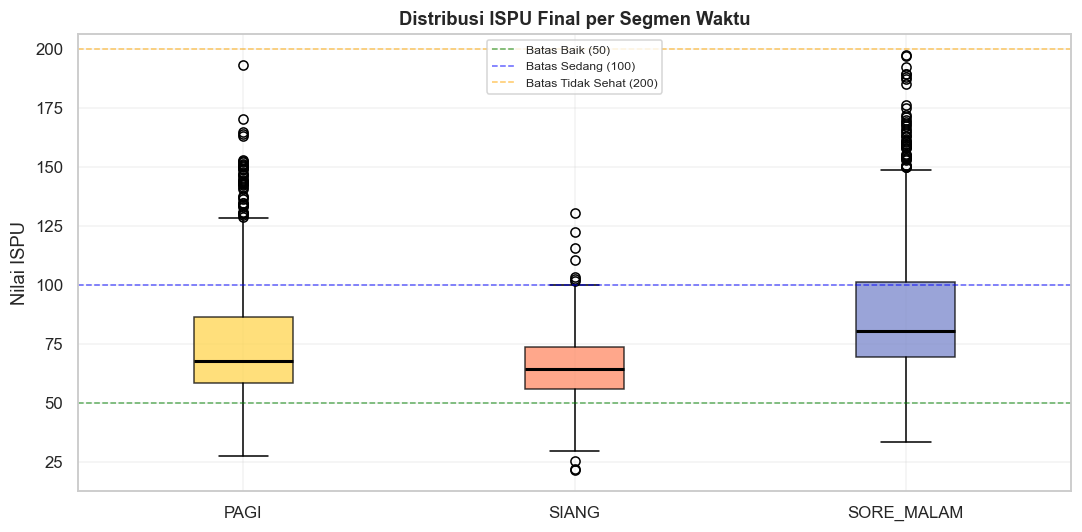

💾 Disimpan → reports/ispu_per_segmen.png


In [32]:
# ── Boxplot ISPU per segmen waktu ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

segment_order = ["PAGI", "SIANG", "SORE_MALAM"]
seg_colors    = ["#FFD54F", "#FF8A65", "#7986CB"]

data_per_seg = [df[df["time_segment"] == seg]["ispu_final"].dropna()
                for seg in segment_order]

bp = ax.boxplot(data_per_seg, labels=segment_order, patch_artist=True,
                medianprops=dict(color="black", linewidth=2))
for patch, color in zip(bp["boxes"], seg_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.axhline(50,  color="green",  ls="--", lw=1, alpha=0.6, label="Batas Baik (50)")
ax.axhline(100, color="blue",   ls="--", lw=1, alpha=0.6, label="Batas Sedang (100)")
ax.axhline(200, color="orange", ls="--", lw=1, alpha=0.6, label="Batas Tidak Sehat (200)")
ax.set_title("Distribusi ISPU Final per Segmen Waktu", fontweight="bold", fontsize=12)
ax.set_ylabel("Nilai ISPU")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig("reports/ispu_per_segmen.png", dpi=110, bbox_inches="tight")
plt.show()
print("💾 Disimpan → reports/ispu_per_segmen.png")

## 9. Drop Baris dengan NaN pada Fitur Lag/Rolling (awal series)
Fitur lag_24h menyebabkan NaN di 24 baris pertama — ini normal, di-drop.

In [33]:
shape_before = df.shape

# Kolom penting yang tidak boleh NaN
critical_cols = [f"{p}_lag_24h" for p in POLUTAN]
df = df.dropna(subset=critical_cols).reset_index(drop=True)

# Isi sisa NaN pct_change (baris pertama) dengan 0
pct_cols = [f"{p}_pct_change_1h" for p in POLUTAN]
df[pct_cols] = df[pct_cols].fillna(0)

print(f"Shape sebelum drop: {shape_before}")
print(f"Shape setelah drop: {df.shape}")
print(f"Baris yang di-drop: {shape_before[0] - df.shape[0]} (normal — warmup lag)")
print(f"\nTotal NaN tersisa: {df.isnull().sum().sum()}")

Shape sebelum drop: (3096, 69)
Shape setelah drop: (3072, 69)
Baris yang di-drop: 24 (normal — warmup lag)

Total NaN tersisa: 0


## 10. Simpan Data Processed (sebelum scaling)

In [34]:
processed_path = "data/processed/surabaya_processed.csv"
df.to_csv(processed_path, index=False)

print(f"✅ Data processed tersimpan → {processed_path}")
print(f"   Shape : {df.shape}")
print(f"   Kolom : {len(df.columns)} total")
print()

# Cetak daftar semua kolom yang ada
pd.set_option("display.max_rows", 80)
summary_cols = pd.DataFrame({
    "Kolom"    : df.columns,
    "Tipe"     : df.dtypes.values,
    "Non-Null" : df.notnull().sum().values,
    "NaN"      : df.isnull().sum().values,
})
display(summary_cols)

✅ Data processed tersimpan → data/processed/surabaya_processed.csv
   Shape : (3072, 69)
   Kolom : 69 total



,Kolom,Tipe,Non-Null,NaN
0,time,datetime64[ns],3072,0
1,pm25,float64,3072,0
2,pm10,float64,3072,0
3,co,float64,3072,0
4,no2,float64,3072,0
5,o3,float64,3072,0
6,temperature_2m,float64,3072,0
7,relative_humidity,int64,3072,0
8,wind_speed_10m,float64,3072,0
9,wind_direction_10m,int64,3072,0


## 11. Normalisasi – StandardScaler
Hanya kolom numerik yang di-scale (kecuali `time`, `time_segment`, `ispu_category`, `ispu_color`)

In [35]:
# Kolom yang TIDAK di-scale
exclude_scale = ["time", "time_segment", "ispu_category",
                 "ispu_color", "is_weekend"]

scale_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in exclude_scale
]

scaler = StandardScaler()
df_scaled             = df.copy()
df_scaled[scale_cols] = scaler.fit_transform(df[scale_cols])

# Simpan scaler & data scaled
joblib.dump(scaler, "models/standard_scaler.pkl")
df_scaled.to_csv("data/processed/surabaya_scaled.csv", index=False)

print(f"✅ StandardScaler fit pada {len(scale_cols)} kolom numerik")
print(f"✅ Scaler disimpan → models/standard_scaler.pkl")
print(f"✅ Data scaled disimpan → data/processed/surabaya_scaled.csv")
print()
print("Statistik data scaled (sample 5 kolom):")
df_scaled[scale_cols[:5]].describe().round(3)

✅ StandardScaler fit pada 64 kolom numerik
✅ Scaler disimpan → models/standard_scaler.pkl
✅ Data scaled disimpan → data/processed/surabaya_scaled.csv

Statistik data scaled (sample 5 kolom):


,pm25,pm10,co,no2,o3
count,3072.000,3072.000,3072.000,3072.000,3072.000
mean,0.000,0.000,-0.000,0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000
min,-1.462,-1.474,-1.289,-1.480,-1.256
25%,-0.695,-0.692,-0.726,-0.753,-0.786
50%,-0.247,-0.235,-0.295,-0.171,-0.316
75%,0.408,0.404,0.426,0.598,0.662
max,5.175,5.190,6.437,7.407,4.084


## 12. Verifikasi Akhir – Validasi Semua Fitur

In [36]:
print("=" * 60)
print("VERIFIKASI FITUR – CHECKLIST MINGGU 2")
print("=" * 60)

checks = {
    "time_segment ada": "time_segment" in df.columns,
    "PAGI/SIANG/SORE_MALAM": set(df["time_segment"].unique()) == {"PAGI", "SIANG", "SORE_MALAM"},
    "Fitur lag pm25_1h": "pm25_lag_1h" in df.columns,
    "Fitur lag pm25_3h": "pm25_lag_3h" in df.columns,
    "Fitur lag pm25_24h": "pm25_lag_24h" in df.columns,
    "Rolling mean 3h": "pm25_rolling_mean_3h" in df.columns,
    "Rolling mean 24h": "pm25_rolling_mean_24h" in df.columns,
    "Rolling std 24h": "pm25_rolling_std_24h" in df.columns,
    "Rolling max 24h": "pm25_rolling_max_24h" in df.columns,
    "diff_1h": "pm25_diff_1h" in df.columns,
    "pct_change_1h": "pm25_pct_change_1h" in df.columns,
    "Fitur waktu: hour": "hour" in df.columns,
    "Fitur waktu: day_of_week": "day_of_week" in df.columns,
    "Fitur waktu: month": "month" in df.columns,
    "Fitur waktu: is_weekend": "is_weekend" in df.columns,
    "ispu_pm25": "ispu_pm25" in df.columns,
    "ispu_pm10": "ispu_pm10" in df.columns,
    "ispu_co": "ispu_co" in df.columns,
    "ispu_no2": "ispu_no2" in df.columns,
    "ispu_o3": "ispu_o3" in df.columns,
    "ispu_final": "ispu_final" in df.columns,
    "ispu_category": "ispu_category" in df.columns,
    "Tidak ada NaN": df.isnull().sum().sum() == 0,
    "StandardScaler tersimpan": os.path.exists("models/standard_scaler.pkl"),
    "CSV processed tersimpan": os.path.exists("data/processed/surabaya_processed.csv"),
    "CSV scaled tersimpan": os.path.exists("data/processed/surabaya_scaled.csv"),
}

all_pass = True
for nama, status in checks.items():
    ikon = "✅" if status else "❌"
    if not status:
        all_pass = False
    print(f"{ikon} {nama}")

print()
if all_pass:
    print("🎉 Semua checklist Minggu 2 (Linda) LULUS!")
else:
    print("⚠️  Ada item yang belum selesai, cek di atas.")

VERIFIKASI FITUR – CHECKLIST MINGGU 2
✅ time_segment ada
✅ PAGI/SIANG/SORE_MALAM
✅ Fitur lag pm25_1h
✅ Fitur lag pm25_3h
✅ Fitur lag pm25_24h
✅ Rolling mean 3h
✅ Rolling mean 24h
✅ Rolling std 24h
✅ Rolling max 24h
✅ diff_1h
✅ pct_change_1h
✅ Fitur waktu: hour
✅ Fitur waktu: day_of_week
✅ Fitur waktu: month
✅ Fitur waktu: is_weekend
✅ ispu_pm25
✅ ispu_pm10
✅ ispu_co
✅ ispu_no2
✅ ispu_o3
✅ ispu_final
✅ ispu_category
✅ Tidak ada NaN
✅ StandardScaler tersimpan
✅ CSV processed tersimpan
✅ CSV scaled tersimpan

🎉 Semua checklist Minggu 2 (Linda) LULUS!


## 13. Ringkasan & Handover Doc Minggu 2

In [37]:
print("=" * 62)
print("RINGKASAN PREPROCESSING – LINDA | MINGGU 2")
print("=" * 62)

print(f"""
📦 Dataset:
   Input  : data/raw/surabaya_airquality_raw.csv
   Output : data/processed/surabaya_processed.csv
            data/processed/surabaya_scaled.csv
   Shape  : {df.shape[0]:,} baris × {df.shape[1]} kolom
   Rentang: {df['time'].min().date()} → {df['time'].max().date()}

🧹 Cleaning:
   Missing values  → interpolasi linear (polutan) + ffill (meteo)
   Duplikasi       → tidak ada / dihapus jika ditemukan
   Warmup lag drop → 24 baris pertama di-drop (normal)

⚙️  Fitur yang dibuat ({len(df.columns)} total kolom):
   Fitur waktu   : hour, day_of_week, month, is_weekend, time_segment
   Fitur lag     : _lag_1h, _lag_3h, _lag_24h × 5 polutan = 15 kolom
   Fitur rolling : _rolling_mean_3h, _mean_24h, _std_24h, _max_24h × 5 = 20 kolom
   Fitur perubahan: _diff_1h, _pct_change_1h × 5 polutan = 10 kolom
   Fitur ISPU    : ispu_pm25, ispu_pm10, ispu_co, ispu_no2, ispu_o3
                   ispu_final, ispu_category, ispu_color
   Meteorologi   : temperature_2m, relative_humidity, wind_speed_10m,
                   wind_direction_10m, precipitation

📊 Distribusi ispu_category:
""")
print(df["ispu_category"].value_counts().to_string())

print(f"""
🗂️  Segmentasi waktu:
""")
print(df["time_segment"].value_counts().to_string())

print("""
🔑 Cara reproduksi:
   1. Pastikan data/raw/surabaya_airquality_raw.csv tersedia
      (jika tidak ada, notebook akan fetch otomatis)
   2. Jalankan notebook ini dari atas (Kernel → Restart & Run All)
   3. Output ada di:
      - data/processed/surabaya_processed.csv  ← untuk ML
      - data/processed/surabaya_scaled.csv     ← fitur ternormalisasi
      - models/standard_scaler.pkl             ← scaler untuk inference
      - reports/*.png                          ← visualisasi

📌 Handover ke Intan:
   - Kolom ispu_category: ['Baik','Sedang','Tidak Sehat',
                           'Sangat Tidak Sehat','Berbahaya']
   - Tolong validasi: apakah kategori match dengan tabel KLHK?
   - File visualisasi ISPU: reports/ispu_kategori_distribusi.png

📌 Handover ke Yuhanidz:
   - Format CSV processed siap di-insert ke DB PostgreSQL
   - Kolom timestamp: 'time' (datetime64, WIB)
   - Sudah ada kolom ispu_final & ispu_category untuk endpoint /ispu
""")

RINGKASAN PREPROCESSING – LINDA | MINGGU 2

📦 Dataset:
   Input  : data/raw/surabaya_airquality_raw.csv
   Output : data/processed/surabaya_processed.csv
            data/processed/surabaya_scaled.csv
   Shape  : 3,072 baris × 69 kolom
   Rentang: 2026-01-02 → 2026-05-09

🧹 Cleaning:
   Missing values  → interpolasi linear (polutan) + ffill (meteo)
   Duplikasi       → tidak ada / dihapus jika ditemukan
   Warmup lag drop → 24 baris pertama di-drop (normal)

⚙️  Fitur yang dibuat (69 total kolom):
   Fitur waktu   : hour, day_of_week, month, is_weekend, time_segment
   Fitur lag     : _lag_1h, _lag_3h, _lag_24h × 5 polutan = 15 kolom
   Fitur rolling : _rolling_mean_3h, _mean_24h, _std_24h, _max_24h × 5 = 20 kolom
   Fitur perubahan: _diff_1h, _pct_change_1h × 5 polutan = 10 kolom
   Fitur ISPU    : ispu_pm25, ispu_pm10, ispu_co, ispu_no2, ispu_o3
                   ispu_final, ispu_category, ispu_color
   Meteorologi   : temperature_2m, relative_humidity, wind_speed_10m,
             

In [38]:
# ── Tulis handover doc ke file .md ──────────────────────────────
handover_md = f"""# Handover Doc – Minggu 2 | Linda Anggara Wati

**Tanggal:** {datetime.today().strftime('%d %B %Y')}  
**Proyek:** Sistem Deteksi Anomali Kualitas Udara – Kelompok Aeris PENS 2026  

---

## Output yang Dihasilkan

| File | Keterangan |
|---|---|
| `data/processed/surabaya_processed.csv` | Data final berfitur lengkap, siap untuk ML |
| `data/processed/surabaya_scaled.csv` | Data yang sudah di-StandardScaler |
| `models/standard_scaler.pkl` | Scaler tersimpan, dipakai saat inference |
| `reports/ispu_kategori_distribusi.png` | Distribusi kategori ISPU |
| `reports/ispu_per_segmen.png` | Boxplot ISPU per segmen waktu |

## Format Data Processed

- **Shape:** {df.shape[0]:,} baris × {df.shape[1]} kolom  
- **Timestamp kolom:** `time` (dtype: datetime64, timezone WIB)  
- **Total fitur engineered:** {df.shape[1]} kolom  

## Daftar Fitur

### Fitur Waktu
`hour`, `day_of_week`, `month`, `is_weekend`, `time_segment`

### Fitur Lag (× 5 polutan)
`[polutan]_lag_1h`, `[polutan]_lag_3h`, `[polutan]_lag_24h`

### Fitur Rolling (× 5 polutan)
`[polutan]_rolling_mean_3h`, `_mean_24h`, `_std_24h`, `_max_24h`

### Fitur Perubahan (× 5 polutan)
`[polutan]_diff_1h`, `[polutan]_pct_change_1h`

### Fitur ISPU
`ispu_pm25`, `ispu_pm10`, `ispu_co`, `ispu_no2`, `ispu_o3`, `ispu_final`, `ispu_category`, `ispu_color`

## Cara Jalankan Ulang

```bash
# Aktifkan venv
source venv/bin/activate  # Linux/Mac
venv\\Scripts\\activate     # Windows

# Jalankan notebook
jupyter notebook notebooks/02_preprocessing.ipynb
# Kernel → Restart & Run All
```

## Catatan untuk Tim

**→ Intan:** Tolong validasi nilai `ispu_category` di kolom output — pastikan cocok 
dengan tabel kategori ISPU KLHK (Baik/Sedang/Tidak Sehat/Sangat Tidak Sehat/Berbahaya).  

**→ Yuhanidz:** File CSV processed siap di-import ke PostgreSQL.  
Kolom `time` bisa langsung jadi primary key timestamp. 
Kolom `ispu_final` dan `ispu_category` sudah siap untuk endpoint `/ispu/surabaya`.
"""

with open("reports/handover_minggu2_linda.md", "w", encoding="utf-8") as f:
    f.write(handover_md)

print("✅ Handover doc tersimpan → reports/handover_minggu2_linda.md")
print("\n🎯 Minggu 2 selesai! Siap lanjut ke Minggu 3: PyCaret 15 Model.")

✅ Handover doc tersimpan → reports/handover_minggu2_linda.md

🎯 Minggu 2 selesai! Siap lanjut ke Minggu 3: PyCaret 15 Model.
